# Characterizing parameter uncertainty with MLE asymptotics

## Exposition

## MLE Asymptotics
Recall that an MLE estimator converges in distribution to a normal distribution:

$$ \sqrt{n}(\hat{\theta}_{mle} - \theta) \to N(0, I^{-1}(\theta))$$

where $I(\theta)$ is the Fisher information matrix. Assuming the asymptotic approximation holds for $n = 6$, we can thus characterize parameter uncertainty by sampling from the distribution 

$$N(\hat{\theta}_{mle}, \hat{V})$$

where $\hat{V} = I^{-1}(\hat{\theta}_{mle})$.

## Reparametrization

Our ultimate parameter of interest is $\theta = (p_0, \xi, \sigma)$ with parameter bounds:

$$ 0 \leq p_0 \leq 1$$
$$ \xi > -1$$
$$ \sigma > 0$$

To obtain estimated parameter distributions respecting these boundaries, we conduct MLE using the following reparametrizations:

$$p_0 = \frac{1}{1 + e^{\phi_1}}$$
$$\xi = -1 + \ln(1 + e^{\phi_2})$$
$$\sigma = \ln({1 + e^{\phi_3}})$$

This gives us $\hat{\phi} = (\hat{\phi_1}, \hat{\phi_2}, \hat{\phi_3})$, which live in unconstrained real number domains. Assuming MLE asymptotics have kicked in these are approximately distributed $N(\hat{\phi}, \hat{V_{\phi}})$.

To obtain parameter distributions over $\theta$, we simply sample from $N(\hat{\phi}, \hat{V_{\phi}})$ and transform back to the constrained space using the inverses of the reparametrization functions.

## Truncation

Recall our modified generalized Pareto Distribution defined by the following cumulative distribution function:

$$
\mathrm{F_X}(x; p_0, \xi, \sigma) = \begin{cases}
     0 & x < \mu \\
     \left(1+\xi\dfrac{x-\mu}{\sigma}\right)^{-1/\xi} & x \geq \mu
\end{cases}
$$

where $p_0$ is the annual probability that an epidemic emerges and $\xi$, $\mu$ and $\sigma$ are the distribution's shape, location, and scale parameters. For simplicity we will henceforth denote $F_X(x;p_0, \xi, \sigma)$ as $F_X$.

Using $1 - F_X$ as the exceedance function and setting a sharp maximum cutof causes the appearance of unappealing modes in the histogram of drawn pandemic severities. We therefore consider two approaches to truncating our distribution more smoothly at some upper bound $\bar{u}$:

1. Simple analytical trunction: We define the exceedance function $EF_X(x) = p_0 \cdot \left(1 - \frac{F_X(x)}{F_X(\bar{u})}\right)$.
2. [Cirillo and Taleb](https://www.nature.com/articles/s41567-020-0921-x) truncation: We transform the data using the transform $\tau(y) = \mu - \bar{u} \cdot \ln\left(\frac{\bar{u} - y}{\bar{u} - \mu}\right)$.

Below I show the consequences of each of these modes of transformation for our parameter and exceedance function distributions.

### Execution and results

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import approx_fprime, minimize
from scipy.stats import genpareto

from pandemic_model.stats.mevd import MEVD, TruncatedGPD
from pandemic_model.stats.utils import taleb_transform, taleb_inverse

In [43]:
rng = np.random.default_rng()
THRESHOLD = 0.01
MAX_INTENSITY = 100

In [44]:
# Load actual duration data
final_allrisk_ds = pd.read_csv("../../data/clean/final_allrisk_ds.csv")

intensity_data = final_allrisk_ds['intensity']
duration_data = final_allrisk_ds['duration']

intensity_annual = final_allrisk_ds.set_index('year_start')['intensity'].copy()

# Fill in zeros for years with no observations.
all_years = pd.Series(range(1900, 2023 + 1))
intensity_annual = intensity_annual.reindex(all_years, fill_value=0)

In [45]:
severity_annual = final_allrisk_ds.set_index('year_start')['severity'].copy()
severity_annual = severity_annual.reindex(all_years, fill_value=0)

In [47]:
intensity_annual[intensity_annual > 0]

1918    56.940515
1957     3.480312
1968     1.407817
1981     2.026815
2009     0.413953
2019     1.834625
Name: intensity, dtype: float64

In [31]:
def prep_excesses(y_raw, lower, upper, method="trunc"):
    """
    Returns (excesses, y_max_for_likelihood, note),
    where `excesses` are measured above `lower`.
    """
    if method == "trunc":
        excesses = y_raw - lower
        y_max = upper
        y_min = 0
    elif method == "taleb":
        excesses = taleb_transform(y_raw, lower, upper)
        y_max = None # now unbounded: no truncation term
        y_min = lower
    else:
        raise ValueError("method must be 'trunc' or 'taleb'")
    return excesses, y_min, y_max

In [32]:
def logit(p):            # (0,1) -> ℝ
    return np.log(p) - np.log1p(-p)

def sigmoid(psi):        # ℝ -> (0,1)
    return 1.0 / (1.0 + np.exp(-psi))

def softplus_inv(z):     # (0,∞) -> ℝ   – inverse of log1p(exp(·))
    return np.log(np.expm1(z))

def softplus(phi):       # ℝ -> (0,∞)
    return np.log1p(np.exp(phi))

def softplus1_inv(xi):   # (-1,∞) -> ℝ   – inverse of log1p(exp(·))-1
    return np.log(np.expm1(xi + 1.0))

def softplus1(phi):      # ℝ -> (-1,∞)
    return np.log1p(np.exp(phi)) - 1.0

def to_phi(theta):
    """θ = (p, ξ, σ)  →  φ = (ψ, φ₁, φ₂)  all in ℝ"""
    p, xi, sigma = theta
    return np.array([logit(p), softplus1_inv(xi), softplus_inv(sigma)])

def from_phi(phi):
    """φ = (ψ, φ₁, φ₂) → θ = (p, ξ, σ)  all valid"""
    psi, phi1, phi2 = phi
    return np.array([sigmoid(psi), softplus1(phi1), softplus(phi2)])

# ------------------------------------------------------------------
# 2.  NEGATIVE LOG-LIKELIHOOD  (optionally truncated)
# ------------------------------------------------------------------
def nll_phi(phi, data, y_min=0, y_max=None):
    """Negative log-likelihood of exceedances y (>0) given φ=(ψ,φ1,φ2)."""
    p, xi, sigma = from_phi(phi)
    
    n = len(data)
    excess_idx = data > y_min
    excesses = data[excess_idx]
    n_exceed = excess_idx.sum()

    # Binomial term for p
    ll = n_exceed * np.log(p) + (n - n_exceed) * np.log1p(-p)
    
    # GPD term for (xi,sigma)
    ll += genpareto.logpdf(excesses, c=xi, scale=sigma).sum()

    # add truncation term if an upper limit exists
    if y_max is not None and np.isfinite(y_max):
        ll -= n_exceed * genpareto.logcdf(y_max, c=xi, scale=sigma)

    return -ll

def grad(f, x, eps=1e-4):
    """Numerical gradient approximation."""
    return approx_fprime(x, f, eps)

def hess(f, x, eps=1e-4):
    """Numerical Hessian approximation."""
    n = len(x)
    H = np.empty((n, n), float)
    ei = np.zeros(n)

    # central differences for second partials
    for i in range(n):
        ei[i] = eps
        for j in range(i, n):
            ej = np.zeros_like(ei)
            ej[j] = eps
            
            H[i, j] = (
                f(x + ei + ej) - f(x + ei - ej)
              - f(x - ei + ej) + f(x - ei - ej)
            ) / (4 * eps * eps)
            H[j, i] = H[i, j]
        ei[i] = 0.0

    # tiny asymmetry/round-off
    return H

# ------------------------------------------------------------------
# 3.  MULTI-START MLE FOR (p,ξ,σ)
# ------------------------------------------------------------------
def fit_tail(data, start_grid, y_min=0, y_max=None):
    results = []
    for p0, xi0, sig0 in start_grid:
        phi0 = to_phi((p0, xi0, sig0))
        
        # Nelder-Mead optimization
        nelder_mead_opts = {
            'maxiter': 10000,
            'maxfev': 50000,
            'xatol': 1e-4,
            'fatol': 1e-4,
            'adaptive': True
        }
        
        opt = minimize(nll_phi, phi0, args=(data, y_min, y_max),
                      method='Nelder-Mead', options=nelder_mead_opts)
        
        if not opt.success:
            error_msg = f"Optimization failed: {opt.message}\n"
            error_msg += f"Status: {opt.status}\n"
            error_msg += f"Number of iterations: {opt.nit}\n"
            error_msg += f"Final function value: {opt.fun}\n"
            error_msg += f"Final parameters: {from_phi(opt.x)}"
            raise RuntimeError(error_msg)
            
        # Calculate full Hessian at optimal point
        info = hess(lambda x: nll_phi(x, data, y_min, y_max), opt.x)
        cov = np.linalg.inv(info)  # asymptotic covariance
        
        est_p, est_xi, est_sigma = from_phi(opt.x)
        results.append({
            "start":   (p0, xi0, sig0),
            "p":       est_p,
            "xi":      est_xi,
            "sigma":   est_sigma,
            "opt":     opt,
            "success": opt.success,
            "fun":     opt.fun,
            "hess_inv": cov
        })
    df = pd.DataFrame(results)
    best = df.loc[df.fun.idxmin()]
    return df, best

def fit_tail_method(y_raw, lower, upper,
                    start_grid,
                    method="trunc"):
    """
    1. Pre-transforms the data depending on `method`.
    2. Calls the original multi-start MLE.
    3. Returns df, best_fit, meta_dict.
    """
    excesses, y_min, y_max = prep_excesses(y_raw, lower, upper, method)
    df, best = fit_tail(excesses, start_grid, y_min=y_min, y_max=y_max)

    meta = dict(method=method,
                data_excesses=excesses,
                y_max=y_max)
    return df, best, meta

In [33]:
lower = THRESHOLD          # the point where "exceedance" begins
upper_bounds = [60, 100, 1000, None]  # different upper bounds to test

# choose your start grid once, it works for both methods
excess_idx = intensity_annual > THRESHOLD
p0 = excess_idx.sum() / len(intensity_annual)
excesses = intensity_annual[excess_idx]

start_grid = [
    (p0,  0.1,  excesses.mean()),
    (p0,  0.5,  excesses.mean()),
    (p0, -0.1,  excesses.std()),
    (p0,  0.2,  np.median(excesses)),
]

# Store results for each upper bound
results = []
for upper in upper_bounds:
    # -------- hard-truncation fit
    df_trunc, best_trunc, meta_trunc = fit_tail_method(
            intensity_annual, lower, upper,
            start_grid,
            method="trunc")

    # -------- Cirillo-Taleb fit (skip if upper is None)
    if upper is not None:
        df_taleb, best_taleb, meta_taleb = fit_tail_method(
                intensity_annual, lower, upper,
                start_grid,
                method="taleb")
        
        # Store results with both methods
        results.append({
            'upper_bound': upper,
            'trunc': {
                'df': df_trunc,
                'best': best_trunc,
                'meta': meta_trunc
            },
            'taleb': {
                'df': df_taleb,
                'best': best_taleb,
                'meta': meta_taleb
            }
        })
    else:
        # Store results with only truncation method
        results.append({
            'upper_bound': upper,
            'trunc': {
                'df': df_trunc,
                'best': best_trunc,
                'meta': meta_trunc
            }
        })

In [34]:
# # Display results for each upper bound
# for result in results:
#     upper = result['upper_bound']
#     print(f"\nResults for upper bound: {upper}")
    
#     if 'taleb' in result:
#         # Quick comparison when both methods are available
#         display(pd.DataFrame({
#             "method" : ["trunc", "taleb"],
#             "p"      : [result['trunc']['best'].p,   result['taleb']['best'].p],
#             "xi"     : [result['trunc']['best'].xi,  result['taleb']['best'].xi],
#             "sigma"  : [result['trunc']['best'].sigma, result['taleb']['best'].sigma],
#             "negLL"  : [result['trunc']['best'].fun, result['taleb']['best'].fun]
#         }))

#         # Display dataframes
#         print("Hard-truncation method results:")
#         display(result['trunc']['df'])

#         print("\nCirillo-Taleb method results:")
#         display(result['taleb']['df'])

#         # Compare covariance matrices
#         print("Hard-truncation method covariance matrix:")
#         display(pd.DataFrame(result['trunc']['best'].hess_inv, 
#                             index=['logit(p)', 'softplus1(xi)', 'softplus(sigma)'],
#                             columns=['logit(p)', 'softplus1(xi)', 'softplus(sigma)']))

#         print("\nCirillo-Taleb method covariance matrix:")
#         display(pd.DataFrame(result['taleb']['best'].hess_inv,
#                             index=['logit(p)', 'softplus1(xi)', 'softplus(sigma)'],
#                             columns=['logit(p)', 'softplus1(xi)', 'softplus(sigma)']))
#     else:
#         # Display only truncation results
#         print("Hard-truncation method results:")
#         display(result['trunc']['df'])
        
#         print("Hard-truncation method covariance matrix:")
#         display(pd.DataFrame(result['trunc']['best'].hess_inv, 
#                             index=['logit(p)', 'softplus1(xi)', 'softplus(sigma)'],
#                             columns=['logit(p)', 'softplus1(xi)', 'softplus(sigma)']))


In [35]:
# ------------------------------------------------------------------
# 5.  MONTE-CARLO DRAWS  →  θ-SPACE
# ------------------------------------------------------------------
n_samples = 20_000

# Draw samples for each upper bound result
param_samples = []
for result in results:
    upper = result['upper_bound']
    
    # Get phi_hat and V_phi from both methods
    trunc_phi_hat = result['trunc']['best'].opt.x
    trunc_V_phi = result['trunc']['best'].hess_inv
    
    # Draw samples for truncation method
    trunc_phi_draws = rng.multivariate_normal(trunc_phi_hat, trunc_V_phi, size=n_samples)
    trunc_theta_draws = np.vstack([from_phi(phi_row) for phi_row in trunc_phi_draws])
    trunc_p_draws, trunc_xi_draws, trunc_sigma_draws = np.hsplit(trunc_theta_draws, 3)
    
    # Draw samples for taleb method if available
    if 'taleb' in result:
        taleb_phi_hat = result['taleb']['best'].opt.x
        taleb_V_phi = result['taleb']['best'].hess_inv
        
        taleb_phi_draws = rng.multivariate_normal(taleb_phi_hat, taleb_V_phi, size=n_samples)
        taleb_theta_draws = np.vstack([from_phi(phi_row) for phi_row in taleb_phi_draws])
        taleb_p_draws, taleb_xi_draws, taleb_sigma_draws = np.hsplit(taleb_theta_draws, 3)
    else:
        taleb_p_draws = taleb_xi_draws = taleb_sigma_draws = None
    
    # Store samples
    param_samples.append({
        'upper_bound': upper,
        'trunc_p_draws': trunc_p_draws,
        'trunc_xi_draws': trunc_xi_draws,
        'trunc_sigma_draws': trunc_sigma_draws,
        'taleb_p_draws': taleb_p_draws,
        'taleb_xi_draws': taleb_xi_draws,
        'taleb_sigma_draws': taleb_sigma_draws
    })

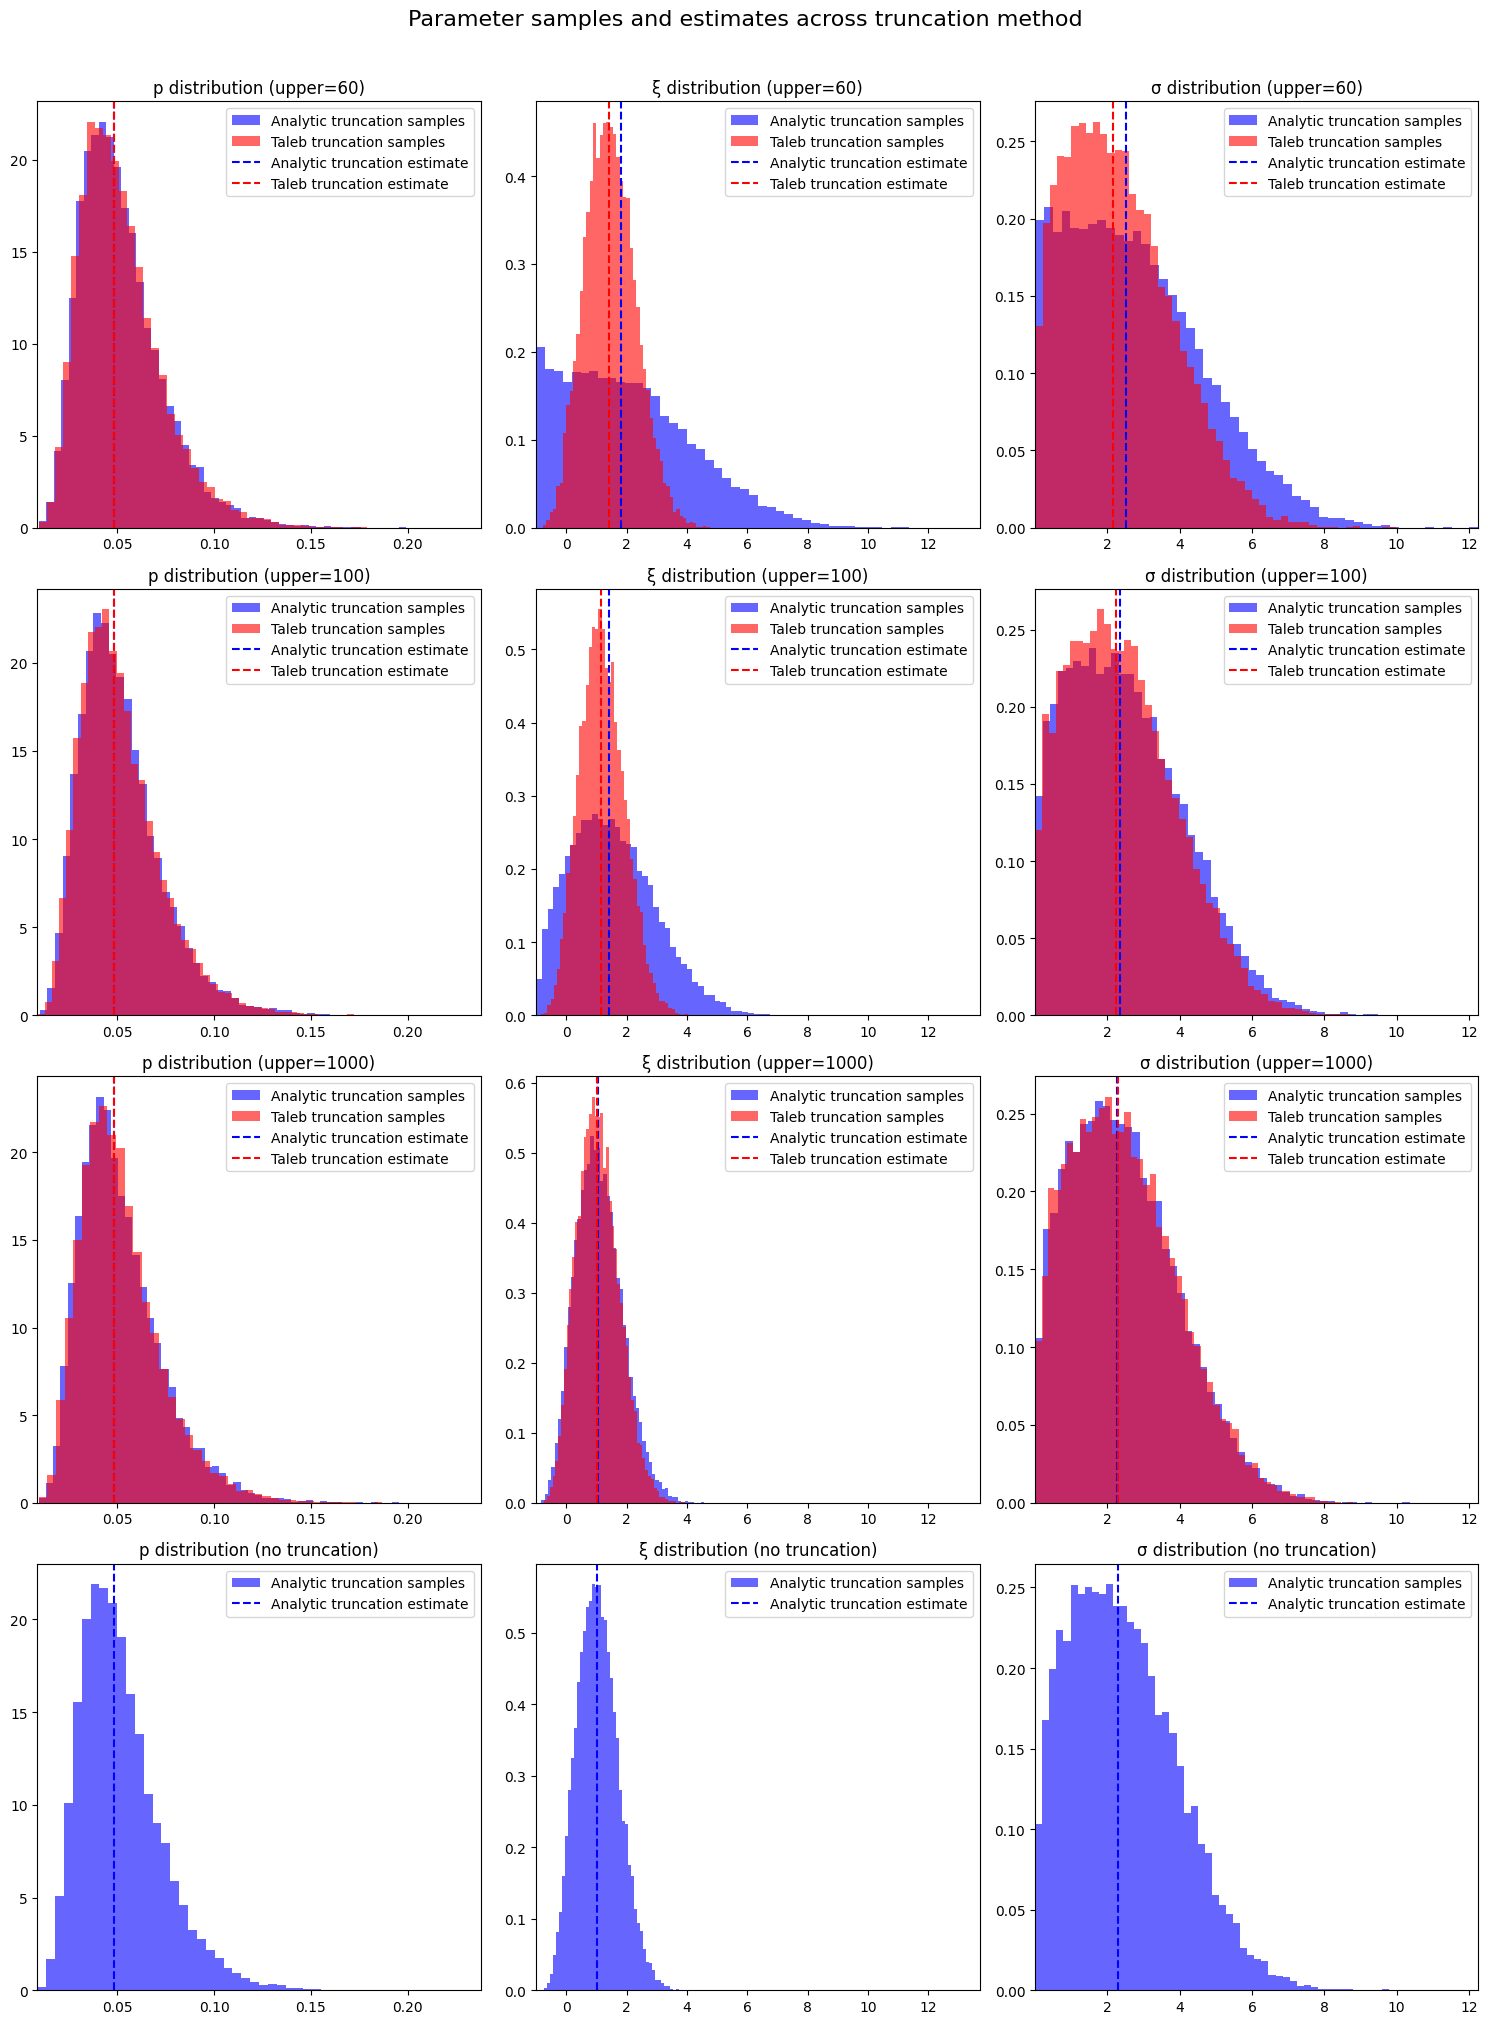

In [36]:
# Create figure with n x 3 subplots where n is number of upper bounds
n_upper_bounds = len(param_samples)
fig, axes = plt.subplots(n_upper_bounds, 3, figsize=(15, 5*n_upper_bounds))

# Get overall min/max for each parameter across all samples
p_min = min(samples['trunc_p_draws'].min() for samples in param_samples)
p_max = max(samples['trunc_p_draws'].max() for samples in param_samples)
xi_min = min(samples['trunc_xi_draws'].min() for samples in param_samples)
xi_max = max(samples['trunc_xi_draws'].max() for samples in param_samples)
sigma_min = min(samples['trunc_sigma_draws'].min() for samples in param_samples)
sigma_max = max(samples['trunc_sigma_draws'].max() for samples in param_samples)

# Plot for each upper bound result
for i, samples in enumerate(param_samples):
    upper = samples['upper_bound']
    
    # Get samples and central estimates for both methods
    trunc_p_draws = samples['trunc_p_draws']
    trunc_xi_draws = samples['trunc_xi_draws']
    trunc_sigma_draws = samples['trunc_sigma_draws']
    
    taleb_p_draws = samples['taleb_p_draws']
    taleb_xi_draws = samples['taleb_xi_draws']
    taleb_sigma_draws = samples['taleb_sigma_draws']
    
    # Get central estimates from both methods
    trunc_phi_hat = results[i]['trunc']['best'].opt.x
    trunc_theta_hat = from_phi(trunc_phi_hat)
    
    if 'taleb' in results[i]:
        taleb_phi_hat = results[i]['taleb']['best'].opt.x
        taleb_theta_hat = from_phi(taleb_phi_hat)
    
    # Plot marginal distributions with both methods
    axes[i,0].hist(trunc_p_draws, bins=50, density=True, alpha=0.6, label='Analytic truncation samples', color='blue')
    if taleb_p_draws is not None:
        axes[i,0].hist(taleb_p_draws, bins=50, density=True, alpha=0.6, label='Taleb truncation samples', color='red')
    axes[i,0].axvline(trunc_theta_hat[0], color='blue', linestyle='--', label='Analytic truncation estimate')
    if 'taleb' in results[i]:
        axes[i,0].axvline(taleb_theta_hat[0], color='red', linestyle='--', label='Taleb truncation estimate')
    axes[i,0].set_title(f'p distribution (upper={upper:.0f})' if upper is not None else 'p distribution (no truncation)')
    axes[i,0].set_xlim(p_min, p_max)
    axes[i,0].legend()
    
    axes[i,1].hist(trunc_xi_draws, bins=50, density=True, alpha=0.6, label='Analytic truncation samples', color='blue')
    if taleb_xi_draws is not None:
        axes[i,1].hist(taleb_xi_draws, bins=50, density=True, alpha=0.6, label='Taleb truncation samples', color='red')
    axes[i,1].axvline(trunc_theta_hat[1], color='blue', linestyle='--', label='Analytic truncation estimate')
    if 'taleb' in results[i]:
        axes[i,1].axvline(taleb_theta_hat[1], color='red', linestyle='--', label='Taleb truncation estimate')
    axes[i,1].set_title(f'ξ distribution (upper={upper:.0f})' if upper is not None else 'ξ distribution (no truncation)')
    axes[i,1].set_xlim(xi_min, xi_max)
    axes[i,1].legend()
    
    axes[i,2].hist(trunc_sigma_draws, bins=50, density=True, alpha=0.6, label='Analytic truncation samples', color='blue')
    if taleb_sigma_draws is not None:
        axes[i,2].hist(taleb_sigma_draws, bins=50, density=True, alpha=0.6, label='Taleb truncation samples', color='red')
    axes[i,2].axvline(trunc_theta_hat[2], color='blue', linestyle='--', label='Analytic truncation estimate')
    if 'taleb' in results[i]:
        axes[i,2].axvline(taleb_theta_hat[2], color='red', linestyle='--', label='Taleb truncation estimate')
    axes[i,2].set_title(f'σ distribution (upper={upper:.0f})' if upper is not None else 'σ distribution (no truncation)')
    axes[i,2].set_xlim(sigma_min, sigma_max)
    axes[i,2].legend()

plt.suptitle("Parameter samples and estimates across truncation method", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

C:\Users\squaade\Documents\Github\pandemic_model\python\pandemic_model\stats\utils.py:17: RuntimeWarning: divide by zero encountered in log
  return lower - upper * np.log((upper - x) / (upper - lower))


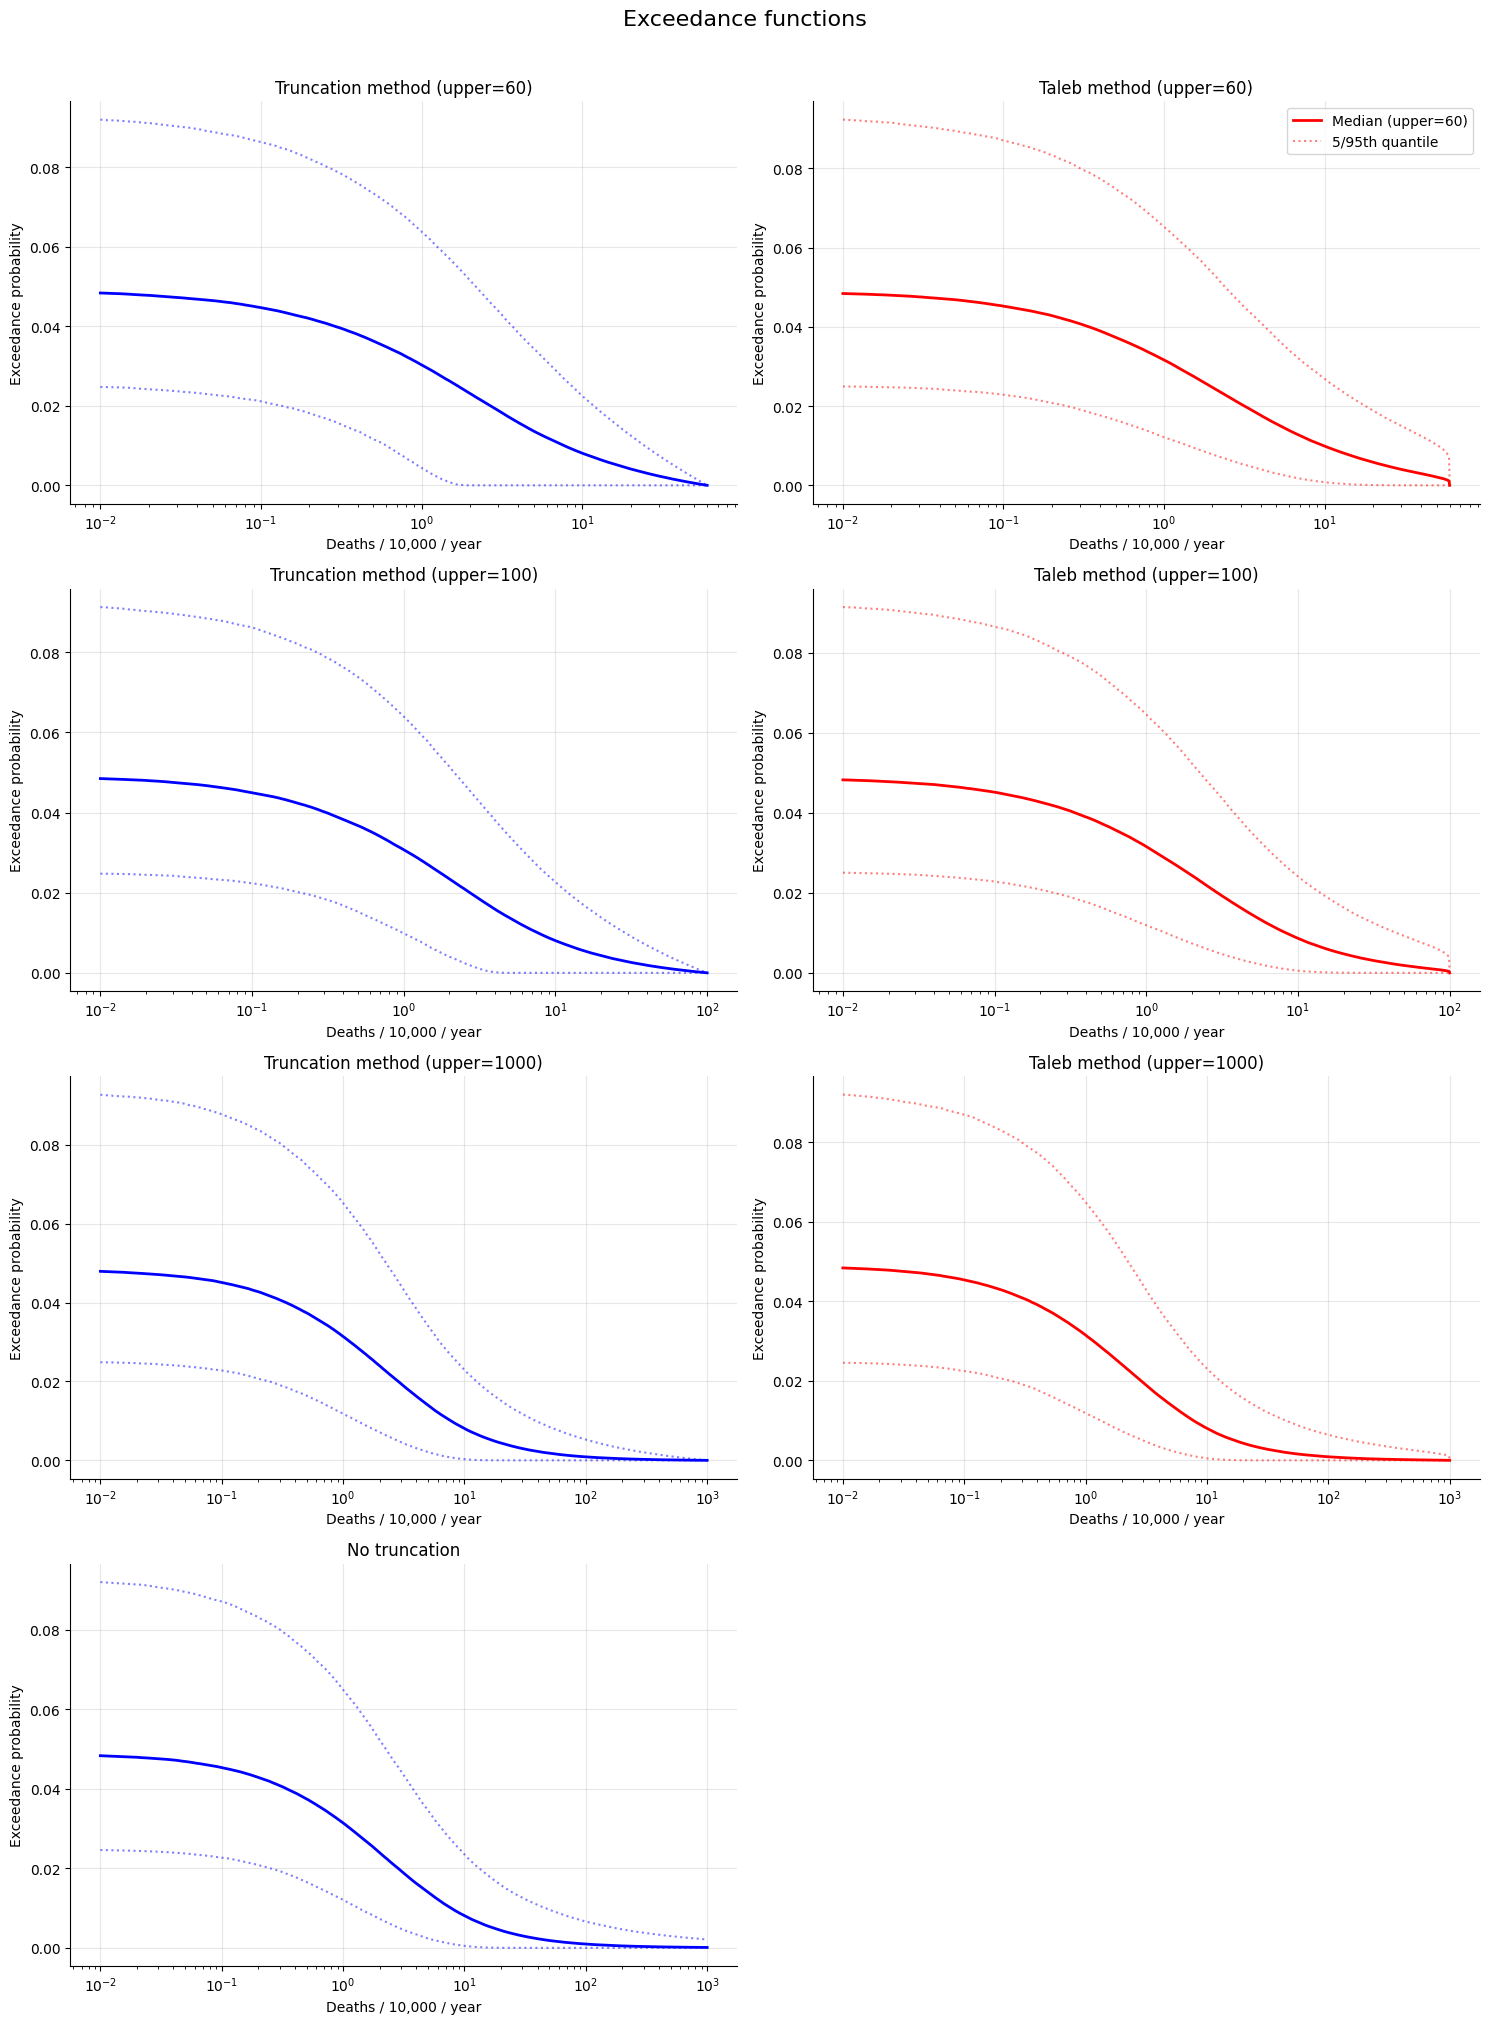

<Figure size 640x480 with 0 Axes>

In [37]:
# Create figure with n x 2 subplots where n is number of upper bounds
n_upper_bounds = len(param_samples)
fig, axes = plt.subplots(n_upper_bounds, 2, figsize=(15, 5*n_upper_bounds))

# Plot for each upper bound result
for i, samples in enumerate(param_samples):
    upper = samples['upper_bound']
    trunc_p_draws = samples['trunc_p_draws']
    trunc_xi_draws = samples['trunc_xi_draws']
    trunc_sigma_draws = samples['trunc_sigma_draws']
    
    # Get Taleb parameter draws if available
    taleb_p_draws = samples['taleb_p_draws']
    taleb_xi_draws = samples['taleb_xi_draws']
    taleb_sigma_draws = samples['taleb_sigma_draws']
    
    upper_x = upper if upper is not None else 1000
    x = np.logspace(np.log10(THRESHOLD), np.log10(upper_x), 1000)
    x_mat = np.tile(x, (n_samples, 1))
    
    # Calculate survival functions for each sample with truncation
    if upper is not None:
        # Calculate CDF at upper bound for normalization
        upper_cdf = genpareto.cdf(upper, trunc_xi_draws, loc=THRESHOLD, scale=trunc_sigma_draws)
        trunc_survivals = (
            trunc_p_draws * (1 - genpareto.cdf(
                x_mat,
                trunc_xi_draws,
                loc=THRESHOLD,
                scale=trunc_sigma_draws
            ) / (upper_cdf)) 
        )
    else:
        trunc_survivals = (
            trunc_p_draws * genpareto.sf(
                x_mat,
                trunc_xi_draws,
                loc=THRESHOLD,
                scale=trunc_sigma_draws
            )
        )
    
    # Calculate percentiles for credible intervals
    trunc_percentiles = np.percentile(trunc_survivals, [5, 50, 95], axis=0)
    
    # Plot on left subplot (truncated)
    axes[i,0].plot(x, trunc_percentiles[1], '-', linewidth=2, 
             label=f'Median (upper={upper:.0f})' if upper is not None else 'Median (no truncation)', color='blue')
    axes[i,0].plot(x, trunc_percentiles[0], ':', alpha=0.5, color='blue')
    axes[i,0].plot(x, trunc_percentiles[2], ':', alpha=0.5, color='blue')
    
    # For Taleb transform, create thresholds over positive domain
    
    # Calculate survival functions with Taleb transformed thresholds
    if upper is not None and taleb_p_draws is not None:
        transformed_thresholds_mat = taleb_transform(x_mat, THRESHOLD, upper)
        
        taleb_survivals = (
            taleb_p_draws * (1 - genpareto.cdf(
                transformed_thresholds_mat,
                taleb_xi_draws,
                loc=THRESHOLD,
                scale=taleb_sigma_draws
            ))
        )
        
        # Calculate percentiles for transformed
        taleb_percentiles = np.percentile(taleb_survivals, [5, 50, 95], axis=0)
        
        # Plot on right subplot (Taleb transformed)
        axes[i,1].plot(x, taleb_percentiles[1], '-', linewidth=2,
                 label=f'Median (upper={upper:.0f})', color='red')
        axes[i,1].plot(x, taleb_percentiles[0], ':', alpha=0.5, color='red', label='5/95th quantile')
        axes[i,1].plot(x, taleb_percentiles[2], ':', alpha=0.5, color='red')
    else:
        axes[i,1].set_visible(False)
        
    for j in range(2):
        axes[i,j].set_xscale('log')
        axes[i,j].grid(True, alpha=0.3)
        axes[i,j].set_xlabel('Deaths / 10,000 / year')
        axes[i,j].set_ylabel('Exceedance probability')
        # Only add legend to first subplot
        if j == 1 and i == 0:
            # Add single handle for both quantile lines
            axes[i,j].legend()
        axes[i,j].spines['top'].set_visible(False)
        axes[i,j].spines['right'].set_visible(False)
    
    # Set titles
    axes[i,0].set_title(f'Truncation method (upper={upper:.0f})' if upper is not None else 'No truncation')
    axes[i,1].set_title(f'Taleb method (upper={upper:.0f})' if upper is not None else 'No transformation')

plt.suptitle("Exceedance functions", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()
plt.savefig("../../output/severity_distributions/allrisk_base_exceedance_fn_grid.jpg", dpi=400)

C:\Users\squaade\Documents\Github\pandemic_model\python\pandemic_model\stats\utils.py:17: RuntimeWarning: divide by zero encountered in log
  return lower - upper * np.log((upper - x) / (upper - lower))
C:\Users\squaade\Documents\Github\pandemic_model\python\pandemic_model\stats\utils.py:17: RuntimeWarning: invalid value encountered in log
  return lower - upper * np.log((upper - x) / (upper - lower))


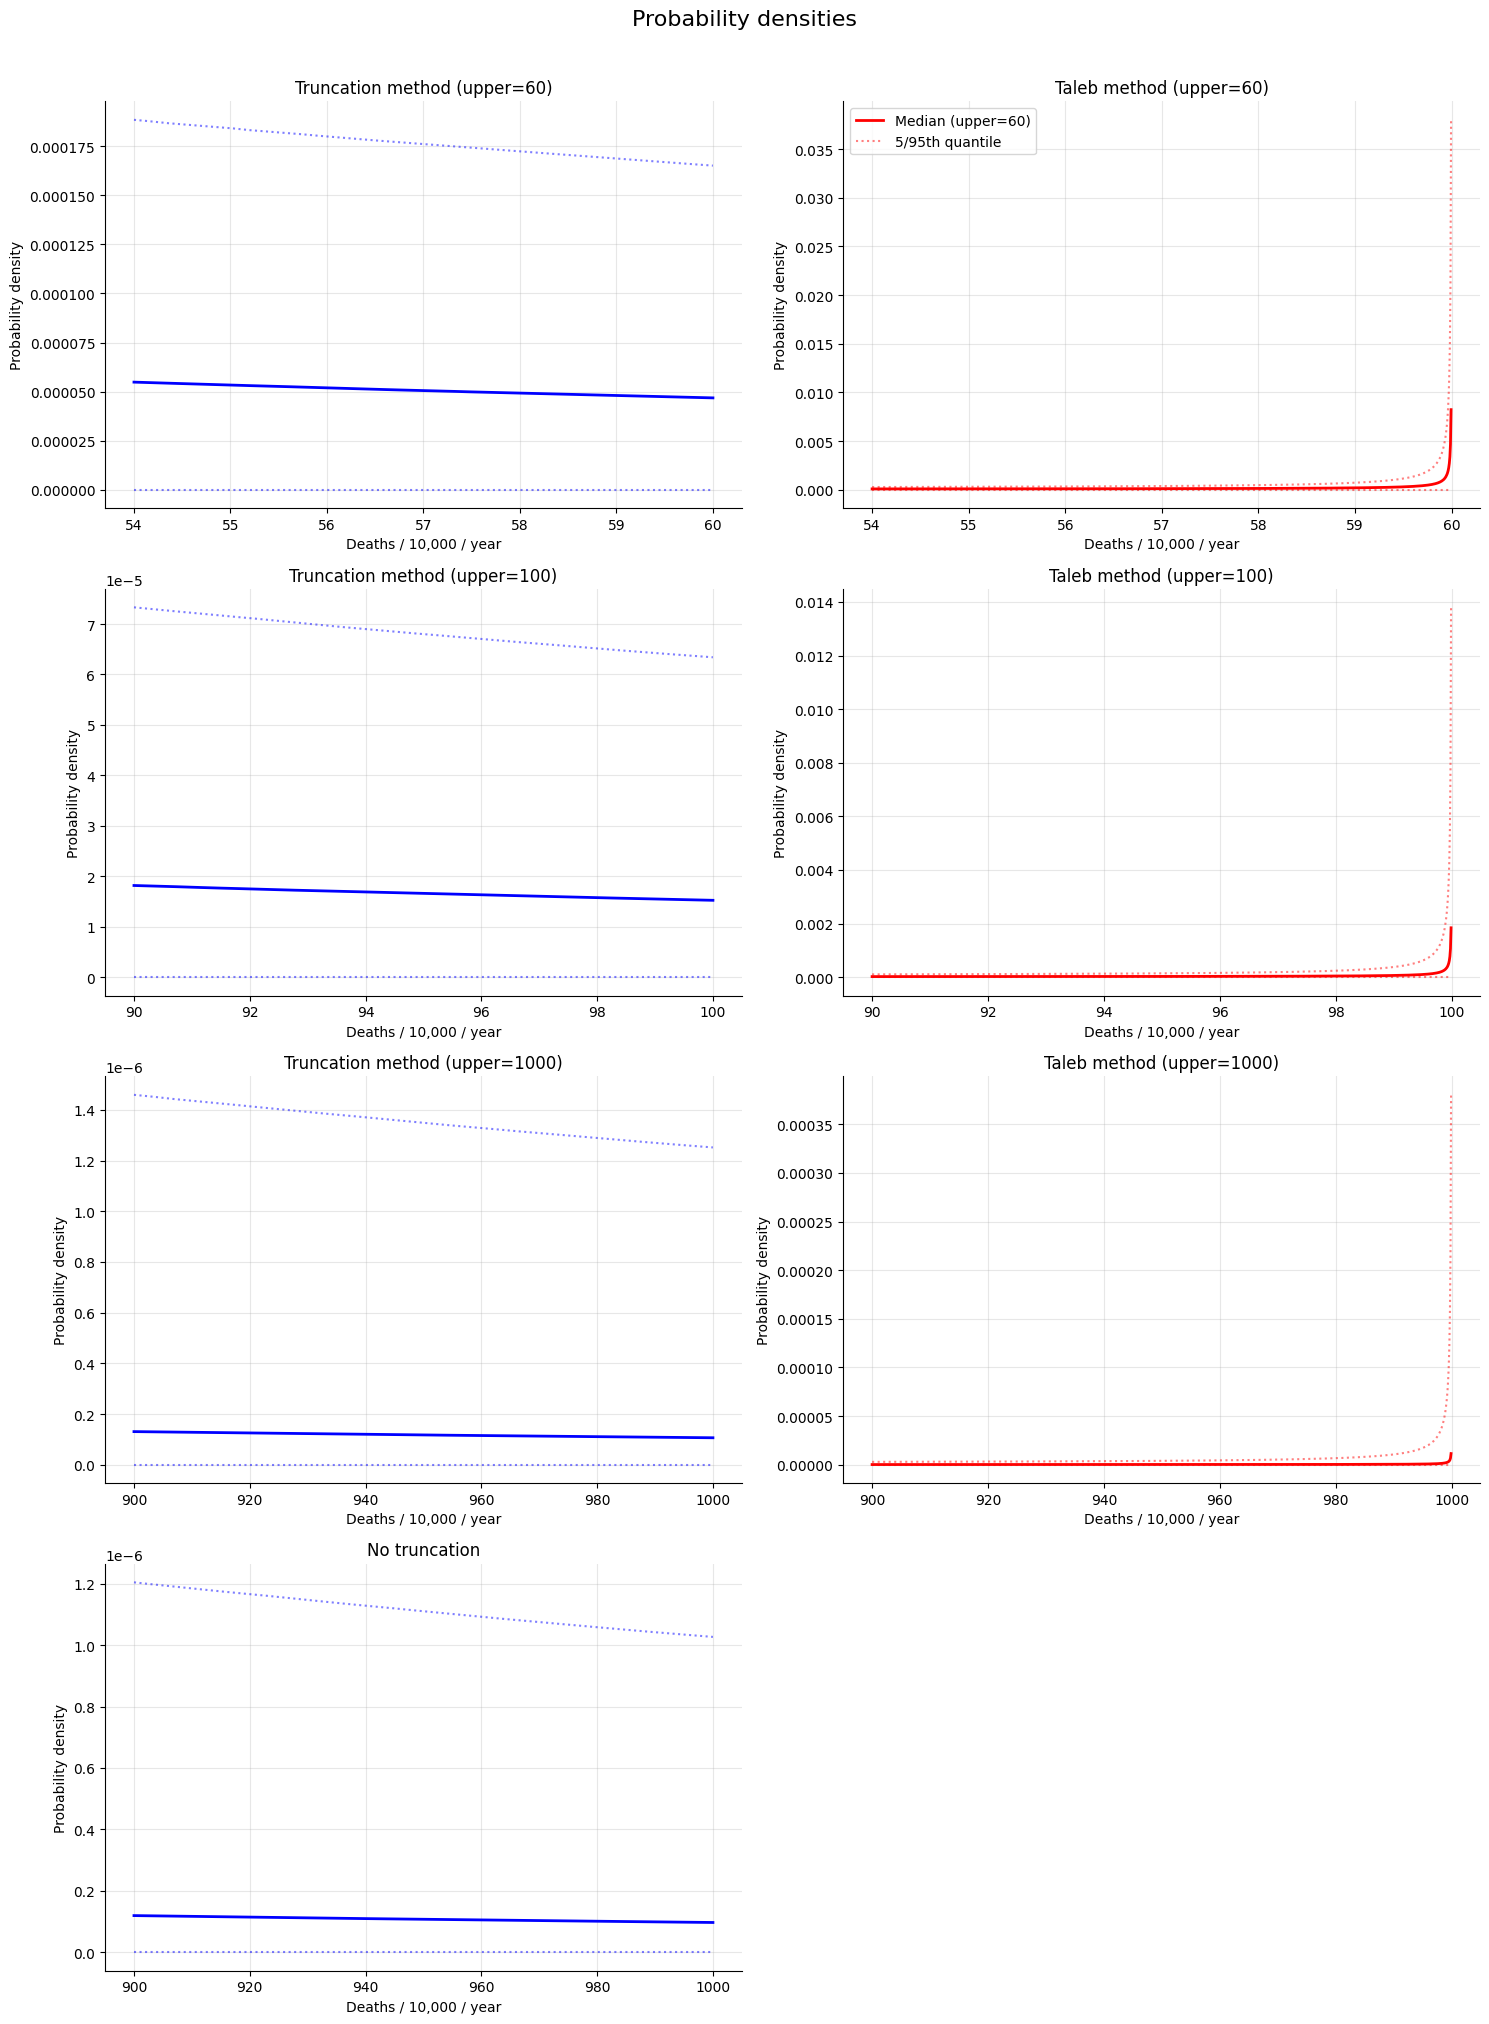

<Figure size 640x480 with 0 Axes>

In [38]:
# Create figure with n x 2 subplots where n is number of upper bounds
n_upper_bounds = len(param_samples)
fig, axes = plt.subplots(n_upper_bounds, 2, figsize=(15, 5*n_upper_bounds))

# Plot for each upper bound result
for i, samples in enumerate(param_samples):
    upper = samples['upper_bound']
    trunc_p_draws = samples['trunc_p_draws']
    trunc_xi_draws = samples['trunc_xi_draws']
    trunc_sigma_draws = samples['trunc_sigma_draws']
    
    # Get Taleb parameter draws if available
    taleb_p_draws = samples['taleb_p_draws']
    taleb_xi_draws = samples['taleb_xi_draws']
    taleb_sigma_draws = samples['taleb_sigma_draws']
    
    upper_x = upper if upper is not None else 1000
    x = np.linspace(upper_x * 0.9, upper_x, 1000)
    x_mat = np.tile(x, (n_samples, 1))
    
    # Calculate PDFs for each sample with truncation
    if upper is not None:
        # Calculate CDF at upper bound for normalization
        upper_cdf = genpareto.cdf(upper, trunc_xi_draws, loc=THRESHOLD, scale=trunc_sigma_draws)
        trunc_pdfs = (
            trunc_p_draws * genpareto.pdf(
                x_mat,
                trunc_xi_draws,
                loc=THRESHOLD,
                scale=trunc_sigma_draws
            ) / upper_cdf
        )
    else:
        trunc_pdfs = (
            trunc_p_draws * genpareto.pdf(
                x_mat,
                trunc_xi_draws,
                loc=THRESHOLD,
                scale=trunc_sigma_draws
            )
        )
    
    # Calculate percentiles for credible intervals
    trunc_percentiles = np.percentile(trunc_pdfs, [5, 50, 95], axis=0)
    
    # Plot on left subplot (truncated)
    axes[i,0].plot(x, trunc_percentiles[1], '-', linewidth=2, 
             label=f'Median (upper={upper:.0f})' if upper is not None else 'Median (no truncation)', color='blue')
    axes[i,0].plot(x, trunc_percentiles[0], ':', alpha=0.5, color='blue')
    axes[i,0].plot(x, trunc_percentiles[2], ':', alpha=0.5, color='blue')
    
    # For Taleb transform, calculate PDFs
    if upper is not None and taleb_p_draws is not None:
        # Take small dx for numerical derivative
        dx = 0.0001
        x_plus_dx = x_mat + dx
        
        # Calculate CDFs at x and x+dx
        cdf_x = taleb_p_draws * genpareto.cdf(
            taleb_transform(x_mat, THRESHOLD, upper),
            taleb_xi_draws,
            loc=THRESHOLD, 
            scale=taleb_sigma_draws
        )
        
        cdf_x_plus_dx = taleb_p_draws * genpareto.cdf(
            taleb_transform(x_plus_dx, THRESHOLD, upper),
            taleb_xi_draws,
            loc=THRESHOLD,
            scale=taleb_sigma_draws
        )
        
        # Numerical derivative
        taleb_pdfs = (cdf_x_plus_dx - cdf_x) / dx
        # Calculate percentiles for transformed
        taleb_percentiles = np.percentile(taleb_pdfs, [5, 50, 95], axis=0)
        
        # Plot on right subplot (Taleb transformed)
        axes[i,1].plot(x, taleb_percentiles[1], '-', linewidth=2,
                 label=f'Median (upper={upper:.0f})', color='red')
        axes[i,1].plot(x, taleb_percentiles[0], ':', alpha=0.5, color='red', label='5/95th quantile')
        axes[i,1].plot(x, taleb_percentiles[2], ':', alpha=0.5, color='red')
    else:
        axes[i,1].set_visible(False)
        
    for j in range(2):
        axes[i,j].grid(True, alpha=0.3)
        axes[i,j].set_xlabel('Deaths / 10,000 / year')
        axes[i,j].set_ylabel('Probability density')
        # Only add legend to first subplot
        if j == 1 and i == 0:
            # Add single handle for both quantile lines
            axes[i,j].legend()
        axes[i,j].spines['top'].set_visible(False)
        axes[i,j].spines['right'].set_visible(False)
    
    # Set titles
    axes[i,0].set_title(f'Truncation method (upper={upper:.0f})' if upper is not None else 'No truncation')
    axes[i,1].set_title(f'Taleb method (upper={upper:.0f})' if upper is not None else 'No transformation')

plt.suptitle("Probability densities", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()
plt.savefig("../../output/severity_distributions/allrisk_base_pdf_grid.jpg", dpi=400)

In [39]:
# Draw 50,000 samples for upper bound of 60
n_samples = 50000
upper = 60

# Find the result with upper bound of 60
result_60 = next(result for result in results if result['upper_bound'] == upper)

# Get phi_hat and V_phi for Taleb method
trunc_phi_hat = result_60['trunc']['best'].opt.x
trunc_V_phi = result_60['trunc']['best'].hess_inv

# Draw samples in phi space and transform to theta space
trunc_phi_draws = rng.multivariate_normal(trunc_phi_hat, trunc_V_phi, size=n_samples)
trunc_theta_draws = np.vstack([from_phi(phi_row) for phi_row in trunc_phi_draws])
trunc_p_draws, trunc_xi_draws, trunc_sigma_draws = np.hsplit(trunc_theta_draws, 3)

# Create DataFrame with samples
trunc_params_df = pd.DataFrame({
    'xi': trunc_xi_draws.flatten(),
    'sigma': trunc_sigma_draws.flatten(),
    'p': trunc_p_draws.flatten(),
    'max_value': upper
})

# Save to CSV
trunc_params_df.to_csv('../../output/severity_distributions/trunc_60_params_samples.csv', index=False)

In [40]:
# First calculate p from the data
trunc_results = result_60['trunc']
mle_p = trunc_results['best'].p
mle_xi = trunc_results['best'].xi
mle_sigma = trunc_results['best'].sigma

print("Direct MLE estimates using scipy genpareto:")
print(f"Shape (xi): {mle_xi:.3f}")
print(f"Scale (sigma): {mle_sigma:.3f}")
print(f"p: {mle_p:.3f}")

Direct MLE estimates using scipy genpareto:
Shape (xi): 1.808
Scale (sigma): 2.529
p: 0.048


In [41]:
# Create DataFrame with MLE estimates repeated n_samples times
mle_params_df = pd.DataFrame({
    'xi': np.repeat(mle_xi, n_samples),
    'sigma': np.repeat(mle_sigma, n_samples), 
    'p': np.repeat(mle_p, n_samples),
    'max_value': np.repeat(upper, n_samples)
})

# Save to CSV
mle_params_df.to_csv('../../output/severity_distributions/trunc_60_params_samples_mle.csv', index=False)